In [ ]:
!pip install -U huggingface_hub hf_xet

In [ ]:
%%bash
set -e
REPO_DIR="/kaggle/working/TempoRun_hf"
REPO_URL="https://github.com/Bamboohoccode/TempoRun_hf.git"

if [[ -d "$REPO_DIR/.git" ]]; then
    echo "Repository đã tồn tại, đang cập nhật..."
    git -C "$REPO_DIR" pull --ff-only
else
    git clone "$REPO_URL" "$REPO_DIR"
fi

In [ ]:
!git -C /kaggle/working/TempoRun_hf status --short

In [ ]:
%cd /kaggle/working/TempoRun_hf/TempoRun2026_Baseline
!pip install -r requirements.txt
!pip install -q -U open_clip_torch ftfy huggingface_hub
!pip install -q "google-cloud-bigquery-storage>=2.0.0"
!pip install -q pillow numpy

In [ ]:
# Cài wrapper OpenCLIP G/384 và vá các CLI cũ trong repo theo cách idempotent.
from pathlib import Path
import base64

BASE_DIR = Path("/kaggle/working/TempoRun_hf/TempoRun2026_Baseline")
WRAPPER_B64 = "IiIiT3BlbkNMSVAgd3JhcHBlciBmb3IgVmlULWdvcHQtMTYtU2lnTElQMi0zODQgU3RhZ2UtMSByZXRyaWV2YWwuIiIiCmZyb20gX19mdXR1cmVfXyBpbXBvcnQgYW5ub3RhdGlvbnMKCmZyb20gdHlwaW5nIGltcG9ydCBTZXF1ZW5jZQoKaW1wb3J0IG51bXB5IGFzIG5wCmltcG9ydCBvcGVuX2NsaXAKaW1wb3J0IHRvcmNoCmltcG9ydCB0b3JjaC5ubiBhcyBubgppbXBvcnQgdG9yY2gubm4uZnVuY3Rpb25hbCBhcyBGCgoKY2xhc3MgQ2xpcE1vZGVsKG5uLk1vZHVsZSk6CiAgICBkZWYgX19pbml0X18oCiAgICAgICAgc2VsZiwKICAgICAgICBtb2RlbF9uYW1lOiBzdHIgPSAiVmlULWdvcHQtMTYtU2lnTElQMi0zODQiLAogICAgICAgIHByZXRyYWluZWQ6IHN0ciB8IE5vbmUgPSAid2VibGkiLAogICAgICAgIHByZWNpc2lvbjogc3RyID0gImZwMTYiLAogICAgICAgIGRldmljZTogc3RyIHwgTm9uZSA9IE5vbmUsCiAgICAgICAgZnJlZXplX3Zpc2lvbjogYm9vbCA9IFRydWUsCiAgICAgICAgbWF4X3RleHRfbGVuZ3RoOiBpbnQgPSA2NCwKICAgICkgLT4gTm9uZToKICAgICAgICBzdXBlcigpLl9faW5pdF9fKCkKICAgICAgICBzZWxmLmRldmljZSA9IHRvcmNoLmRldmljZSgKICAgICAgICAgICAgZGV2aWNlIG9yICgiY3VkYSIgaWYgdG9yY2guY3VkYS5pc19hdmFpbGFibGUoKSBlbHNlICJjcHUiKQogICAgICAgICkKICAgICAgICBpZiBzZWxmLmRldmljZS50eXBlID09ICJjcHUiIGFuZCBwcmVjaXNpb24gIT0gImZwMzIiOgogICAgICAgICAgICBwcmVjaXNpb24gPSAiZnAzMiIKCiAgICAgICAgcHJldHJhaW5lZCA9IE5vbmUgaWYgcHJldHJhaW5lZCBpbiAoTm9uZSwgIiIsICJOb25lIikgZWxzZSBwcmV0cmFpbmVkCiAgICAgICAgc2VsZi5tb2RlbCwgc2VsZi5wcmVwcm9jZXNzX3RyYWluLCBzZWxmLnByZXByb2Nlc3NfdmFsID0gKAogICAgICAgICAgICBvcGVuX2NsaXAuY3JlYXRlX21vZGVsX2FuZF90cmFuc2Zvcm1zKAogICAgICAgICAgICAgICAgbW9kZWxfbmFtZSwKICAgICAgICAgICAgICAgIHByZXRyYWluZWQ9cHJldHJhaW5lZCwKICAgICAgICAgICAgICAgIHByZWNpc2lvbj1wcmVjaXNpb24sCiAgICAgICAgICAgICAgICBkZXZpY2U9c2VsZi5kZXZpY2UsCiAgICAgICAgICAgICkKICAgICAgICApCiAgICAgICAgc2VsZi5tb2RlbC5ldmFsKCkKICAgICAgICB0cnk6CiAgICAgICAgICAgIHNlbGYudG9rZW5pemVyID0gb3Blbl9jbGlwLmdldF90b2tlbml6ZXIoCiAgICAgICAgICAgICAgICBtb2RlbF9uYW1lLCBjb250ZXh0X2xlbmd0aD1tYXhfdGV4dF9sZW5ndGgKICAgICAgICAgICAgKQogICAgICAgIGV4Y2VwdCBUeXBlRXJyb3I6CiAgICAgICAgICAgIHNlbGYudG9rZW5pemVyID0gb3Blbl9jbGlwLmdldF90b2tlbml6ZXIobW9kZWxfbmFtZSkKCiAgICAgICAgaWYgZnJlZXplX3Zpc2lvbjoKICAgICAgICAgICAgZm9yIHBhcmFtZXRlciBpbiBzZWxmLm1vZGVsLnZpc3VhbC5wYXJhbWV0ZXJzKCk6CiAgICAgICAgICAgICAgICBwYXJhbWV0ZXIucmVxdWlyZXNfZ3JhZF8oRmFsc2UpCgogICAgICAgIHNlbGYubW9kZWxfZHR5cGUgPSBuZXh0KHNlbGYubW9kZWwudmlzdWFsLnBhcmFtZXRlcnMoKSkuZHR5cGUKICAgICAgICBzZWxmLm5wX2R0eXBlID0gKAogICAgICAgICAgICBucC5mbG9hdDE2IGlmIHNlbGYubW9kZWxfZHR5cGUgPT0gdG9yY2guZmxvYXQxNiBlbHNlIG5wLmZsb2F0MzIKICAgICAgICApCiAgICAgICAgc2VsZi5kaW0gPSBpbnQoCiAgICAgICAgICAgIGdldGF0dHIoc2VsZi5tb2RlbC52aXN1YWwsICJvdXRwdXRfZGltIiwgMCkKICAgICAgICAgICAgb3IgZ2V0YXR0cihnZXRhdHRyKHNlbGYubW9kZWwsICJ0ZXh0IiwgTm9uZSksICJvdXRwdXRfZGltIiwgMCkKICAgICAgICAgICAgb3IgMTUzNgogICAgICAgICkKCiAgICBAdG9yY2guaW5mZXJlbmNlX21vZGUoKQogICAgZGVmIGVuY29kZV9pbWFnZXMoCiAgICAgICAgc2VsZiwgcGlsX2ltYWdlczogU2VxdWVuY2UsIGJhdGNoX3NpemU6IGludCA9IDQKICAgICkgLT4gbnAubmRhcnJheToKICAgICAgICBmZWF0dXJlczogbGlzdFtucC5uZGFycmF5XSA9IFtdCiAgICAgICAgZm9yIHN0YXJ0IGluIHJhbmdlKDAsIGxlbihwaWxfaW1hZ2VzKSwgYmF0Y2hfc2l6ZSk6CiAgICAgICAgICAgIGJhdGNoID0gWwogICAgICAgICAgICAgICAgc2VsZi5wcmVwcm9jZXNzX3ZhbChpbWFnZSkKICAgICAgICAgICAgICAgIGZvciBpbWFnZSBpbiBwaWxfaW1hZ2VzW3N0YXJ0IDogc3RhcnQgKyBiYXRjaF9zaXplXQogICAgICAgICAgICBdCiAgICAgICAgICAgIGlmIG5vdCBiYXRjaDoKICAgICAgICAgICAgICAgIGNvbnRpbnVlCiAgICAgICAgICAgIHBpeGVscyA9IHRvcmNoLnN0YWNrKGJhdGNoKS50bygKICAgICAgICAgICAgICAgIHNlbGYuZGV2aWNlLCBkdHlwZT1zZWxmLm1vZGVsX2R0eXBlLCBub25fYmxvY2tpbmc9VHJ1ZQogICAgICAgICAgICApCiAgICAgICAgICAgIG91dHB1dCA9IHNlbGYubW9kZWwuZW5jb2RlX2ltYWdlKHBpeGVscykKICAgICAgICAgICAgb3V0cHV0ID0gRi5ub3JtYWxpemUob3V0cHV0LmZsb2F0KCksIGRpbT0tMSkKICAgICAgICAgICAgZmVhdHVyZXMuYXBwZW5kKG91dHB1dC5jcHUoKS5udW1weSgpLmFzdHlwZShzZWxmLm5wX2R0eXBlKSkKICAgICAgICBpZiBmZWF0dXJlczoKICAgICAgICAgICAgcmV0dXJuIG5wLmNvbmNhdGVuYXRlKGZlYXR1cmVzLCBheGlzPTApCiAgICAgICAgcmV0dXJuIG5wLnplcm9zKCgwLCBzZWxmLmRpbSksIGR0eXBlPXNlbGYubnBfZHR5cGUpCgogICAgQHRvcmNoLmluZmVyZW5jZV9tb2RlKCkKICAgIGRlZiBlbmNvZGVfdGV4dHMoCiAgICAgICAgc2VsZiwgdGV4dHM6IFNlcXVlbmNlW3N0cl0sIGJhdGNoX3NpemU6IGludCA9IDMyCiAgICApIC0+IG5wLm5kYXJyYXk6CiAgICAgICAgZmVhdHVyZXM6IGxpc3RbbnAubmRhcnJheV0gPSBbXQogICAgICAgIGZvciBzdGFydCBpbiByYW5nZSgwLCBsZW4odGV4dHMpLCBiYXRjaF9zaXplKToKICAgICAgICAgICAgYmF0Y2ggPSBsaXN0KHRleHRzW3N0YXJ0IDogc3RhcnQgKyBiYXRjaF9zaXplXSkKICAgICAgICAgICAgaWYgbm90IGJhdGNoOgogICAgICAgICAgICAgICAgY29udGludWUKICAgICAgICAgICAgdG9rZW5zID0gc2VsZi50b2tlbml6ZXIoYmF0Y2gpLnRvKHNlbGYuZGV2aWNlLCBub25fYmxvY2tpbmc9VHJ1ZSkKICAgICAgICAgICAgb3V0cHV0ID0gc2VsZi5tb2RlbC5lbmNvZGVfdGV4dCh0b2tlbnMpCiAgICAgICAgICAgIG91dHB1dCA9IEYubm9ybWFsaXplKG91dHB1dC5mbG9hdCgpLCBkaW09LTEpCiAgICAgICAgICAgIGZlYXR1cmVzLmFwcGVuZChvdXRwdXQuY3B1KCkubnVtcHkoKS5hc3R5cGUoc2VsZi5ucF9kdHlwZSkpCiAgICAgICAgaWYgZmVhdHVyZXM6CiAgICAgICAgICAgIHJldHVybiBucC5jb25jYXRlbmF0ZShmZWF0dXJlcywgYXhpcz0wKQogICAgICAgIHJldHVybiBucC56ZXJvcygoMCwgc2VsZi5kaW0pLCBkdHlwZT1zZWxmLm5wX2R0eXBlKQo="
wrapper = base64.b64decode(WRAPPER_B64)
(BASE_DIR / "clip_model.py").write_bytes(wrapper)
(BASE_DIR / "clip_model_siglip2.py").write_text(
    "from clip_model import ClipModel\n\n__all__ = ['ClipModel']\n", encoding="utf-8"
)
RETRIEVE_GZ_B64 = "H4sICHxvYWoCA3JldHJpZXZlX2VsaXBfczIucHkA7VtRj+O2EX73r2CVh8g5WbH30kPgREHT5FIckrSHXFIUMAxBlmibsSwponS7m63/e2eGpERK8u5e26eiC9zZEsnhcGY483E49jzvXZMcOHu5Zu/E4Yc3b29YzZta8PdJzl6w1/Bm8W6BL+ukOIniwBZfMdnuzkJKURbhrxL+m80UkRVLy3PVNlwyfpekDUuPbXHiGWvKavE9Sw6JKGTDmiNnVc1134yd+P2+Ts6ciSLjd6EmdsPKiheSlUV+D0NKyVmaFJnIkgZ6nqGLDGDErzxtJPut5fX9Ii2hvQG2gChyPqtqmAOaRdGUZn0fS/ZeIO+sgSXJfVmfeR3oBUpk7hywjGdtlYs0wbW8FxkvZTCD2dltLfAVTMEaceaySc4Vq3jNMiEbUcCaqXc48zxvtofpWRzv26ateRwD11VZNywpirJJkE85m5l39aFKasnN8yEvd+Y7yth8L6X5htOrGdIyz0EKSM9MkfF90uZNJtJG9dm3wFtZ5l2PvG7jNEmPmkaVNMdc7EzrW3jseCvac3XPEsmKajabAWmWl0kWk7Z8eUzqLM5EvWayqefrGYM/ft7xLANrARWRPGKRwddOYvA9L9MkRxoiBXlGbLMNrH9EZS9yapLABM98FEmI//mlDJHf8NdSFD0DAfM+CYvqd28+n9P4ArQE6r+PlQKB0lJxd1eBuDgOOsPLv0K3mZqwrGnSQhmjYkCtCP9uRXMEGYS4et/0C1iS5+VtXIn0lPPouySXfI7CAjtN+rH4J/bMA8l4wFiD5LEHgym9RsZn6bx2B+JfnQjYAX9P8pa/ruuy9vfeg+Hhws4t7Csw/wZ2GEqfoa0qsnOHFLZFuIhEJnWd3Ps424bY2ro9afRUX0UWes+shQGBsEB5/iFiNy73j3K+Jo6I/R1nm+8D9i0YwAEk8YAkQbkVv1hrgKlgpE88zHEyfIKe8yfmHMnTZeLBkLlYtst2baNa1HQXy4A9h+B8KArie7PcsgiMzmUNtSSKljtDbIsUkkzSHTWw2X6O1bbrx3Nn9tUW5WMP/M9kBASiB5v8Jeiog7aseS5D6XSPxhnAEtDFdLtoHsqGn2eWlWodhEkFUSAj3YyoyJDfNdi6MW+27BNH/v2YXnWGpFJq18FxSIYwxIQD9x2K/Yihf3kRsZVaKugBN3O/jF7ySurv7nG9r+9EA7uhKJHUgmgxcmcYsdhD59lwA8yc3QtGhLGpgH++7WyTOyGjpWIRuBrs305uqkMjx8RsF62JwfDmvuI+9IQ4+uozNViLK7tzp3CkCHEUR0Zq5MsbNbKq4aE3tr23oUiytTehgQSSUXR6GIj6YmIy8yw6UwaqGKC39PXiBf2IvJXH6Oe65eqdYg/gT1uTE6XYhWGrD1fZnY6ANYcI2CTyJDsbtgMghQrEL1ac4EVaopoir232i889ihIwhCfWxiSSGA4JWGGkkX4uCggpGJzwG5qGGkXOEN7A3qlF5c+3XRBDKtiPqK1tT+PhK1hHF22oKwahjMsUyCCMcBqfcBre6/cAvRSZgnMwOT0DhSCbqCNe4kzLUqPEGFDiyR/ghzUaV5GRcSktIdQTfKIh4+/B6EgL6sVpjcBPfScTi2mmWIrfudVE2DHeJU16HDbJtATgRoZj0a15AaAxyaGvAkFrtgNoFcy08gH6vSb4q2Dv7RFMACyaVwifEfy6gBcF/c3bX9iZn8v6PkTgSBxrmFfW6bHzKpZjtJ28lkn3buhurjn5vfeGOMCg8jBB+2KI36suw3ksR689FLGrJAZWTE/hHsy4Wb1C/i2BYmj09tXqlQeBC3i0+r680bQa2HN6zkA/aregAr9umwcGBugFKFM7Qa8zIMSTO9bYoQSAHL9HyWg/SB7G9wfTnuaWG9PsOSR6DPs8GtqJdpv1txgcbk37TYWbZTBc+tBELbTzWwxxSi/UUHoxGjCg2Mcw1RGcP4DsTmGJ1G9ca9GDN3qaNU29DfTGi9SHWehYnS5Qmpy4KEI6qIC7SPKw22W+3TkgILJYXSVlP4ZN6Vv8KMvrRyoB6XXhUBLmwqikxy2wk3tT0Utr89yVj++QI627uw2F4XsLUey9QZMrQrdpLM5gQp7IYW+JqvvvvC7lkzw+pr+8LA6zCRyHdnvNatUuC0YudwDRe7M1RjscMLVtOxRNvYpKYWG97TfKLtEqx50nrNsQeY4Jz4dHuXEUGOFnd95rxk29xlZtE6DPK7bsDPiIfVMWEJAb5WkhGJdsX728gcMVqIxTRDrhy5pnbcohYif1ohEYiUB2O5GL5j50KEpxFnlSi0btEGcrsj9pzn6eKzH5U0oaWmWi7IV0hagoG4h/DuC7AvAwPo8MbFftVbVTp09jxIRJGg03MGBef9Nv7MBZ6lYpZHWN1nBRSGzE78balIErDUP/EcYd1niuzlnRaD0hwabTJL9TTuEA5y4Otj9cSsBW/TyWWTmBcuD7iajhMkyr1p+HlC2yDMGNktMEzKnLpWDjRYeLYEAUcGSaJ1Ky7zWw+onLModtoLbkmx+//svr+N0v33335h+v38GUD174a3Xw4PQAn1x9qQr1ect3lXeZaUS5ZzFMIpo49kE0e5i4LBsb6NMWgZYQG8ypFr9r9v/U5dn8c3KHXi1aLW/0GQrpK+emqZsDmpoBU61NW+V8g1QDFoahhezgXAiqAsSIGbKOg087GjbqRzjf9Q+FxEOlP0yZKEE7mlNQHVlwjVtn5EYGj1m5cRYBHAU2UG6rZ6LhNXEx6g/8UnYP2MTDkz+nkwS9ku1+L+4gKt2CBc/pJIQrdxV8ZUvNe53WyjymhG4lJhHXA1YjNaAC2D8HeZkOihITWpGGmpMSWrIvI5sw+5IAqw5sk3pQbRtr0HaoGJW41EeospQArAUYPXx2m1tH/7q8nTgwqRAxft+lCcZNYMNxxWt1DNcHJc1/WrZFIzFNlDYbkiS04ga3ctE+ynOm94xxaJv+3Ap8Boot1O3vcKhFzvUrW1BWHgmm6hMbG+i/dUSv2LISRF9Fg1U8np0zjJqsES4BuQLcpEIe8Ta30kKjGSkvZOnNkOxSCXjzQMkE3zqQ7nmC1wZjHfTKNcdRHM+7w6l2fSNn+KRy+9zPuM3J60wMxShAKRnr9KwXNn2yxjueVXzLxeEIDpVE2ZnSR2DaoKQK71XAc6anqoSBa1a3hbk8auBgi9c85tLKXEDhbVHI2LeYUms0McI2oFa8OELcSvZFGZqkYKArTQqYzfAmhO6M9PThrEN7Ssjj7KwKRbI3ZPxrJc/6awfJbWTUGXqMRt5r0zXEZ1q4Zq/rDRStuScg6dC+rSV0Jm6o0Ra2UoJq7rk7uzVdmGTZhAO08vZ6pjnuQstmxkiv5slp6O82TrcHDzXirVFvgH48My+86fn3aAfgfcWama+X2TA6KQrWsk1XCjEc8Ahov+GG+0BhThtsbfVxHpOVb9/8YJI3b/CactbbkNqIEzY0yqqZzesMqvlvLQTQjN0eeUE3nPiWF8ku55nJEZurUYBKIrMiQXfHNvC2aiN2TnfKHp/rbXHmmEJ91PEdmmDrGpXjT7Rd2W7bojV5HzKy46a+d3vQBicFhJSI7SlS4pUex4anpGd2Aj1hfhyPVL7301/+7A2sfyjlbg+NhGsN5HcpBxfj/+0daTuwND+/skx6u4N9GO90Ehxx7GVmi8vSGM9FFesjYNQ5r1B9GWd1umgTOU9uIqISoDCaJ9I2Nhsfzgjhjhz/VMICLXBCSoHFuwEBj0rcHiD7eVw57gWcuTVROMSO1O6EI/aJw9Ko8wvmr8KlOnr2o+YwTCGCnp/5I8e7D3DwEO/ei7JFVTomEB4gsFz1t90ovYEY3W73cviq67FZbidcsD2ThWamxDcQcTDZAXU9PXIotXE3cxhMqJykKwlwpQFHirP0wYJO/D7Kk/MuSxi+W7MFfmxW2+5GcBS0rwVstNLec/lxoEP3XCe+gJ3Nuo9k2xEu+PCgej2gajzzI9beFIdPQVZ1C35E7UYmj2WbZ3TWOycnzhK0qzaFjZzk+T3MigU3OW+4Zi3U5P6cpCc4aOWDEhbJkhRmyOjSokTcJWowIXFAPSu8tQC8VWcWSnJC/JeTEf7/6Oe56Gc2CX3+C7DnP4c8W310oZKlOKkP0mQT6A1m4U1BU/h1fQBiRfOWWvS2Ut1QYjia2n1vsVCX317QIR26nb0+pFsSjO2ujK0bXn30jDzr3ZHnVQRCvO2v4TBz8kWPrqjijCDWYoFeadGfQdCXoso9+8b4ymLoivP5a4ERZdv8e2sfcPksCZT7vUgFbOWuxi+sQArlWTQqZfP4IetJCYz4q3lVPoszQn3K5bA0p2q+jtn7KhftTjSfEvpFklJgPuk5ClHpZS/op07bLFkvvect4lxmPLdH/138vDiUVbNYvVpoES1efv6Z9wGC6YU8JZlbvsvFSDx/Azf1Da7e0hAo5gs0TB3o0YD1LscjrQIo8jkywrpMqo70MGFdIjqPNuqaFtzKbq8+8UrB21qioA6PEj4ndwvwgYfmCAToFgNzAR0FU1ZybS+V1UJ5y8nRq+WjozHK2P5hgsJny+WT7HcUFhWvFTuTtF4+SolyeQu6DFggNp4kcbNcxssnWFI1rwSyrxPqim6maSik/hSRx2lArFjoQtsPVo69Fwj7LehWa9L4po3uaZO2LuqU8IFYQtdwkScbrEcAmMSf6QQU5F+oHWVtTVq2zmIN9/EyXA738DKq4HxFrvcLpu+lZJse8WS6DFd/ZHCixwpO8IAGaZF4Psjr5mWdfHBUqNT9JKbBsLSa/VD+9DVGBmCtAt8LvkZfJSLvDjsIAyDwa65saGDXxIEwMBmODaF76oK3cKzq0ZAmxFVCZCD6rmQU0MpmGbDV1uumIdq45+O+jOxL9XYKdQ3ncb1FNxFgNscPudPR6cXCCXhl4eN6qbWnBk65e0tjMITNrzDjAEMb4hB5K6wCPW5lhzDzMQYFgzP4Y5xTA5qP1XBNYGQgiTZWB1RYuVsE+rhukCOcQnYU8Jx6MJxRg8ozhDQDJ22bso3p3ygwt2rWlfER1tSVkLrqzqrqU+aCX+2qxb23oXe6WFG1X7zAqiXs7pm6yjc6ZmLXjVNktx2X6m0f00yvgI/YG8ov4tHMlTjdlImKSg/jFMYjaYQEsJ1BDJLd0hkRFJBZ1FBzEoEwQJw254zq3xGA3ZaYycw5uhb1g4WQ/SI1wMAJP5aqrJHXFjlczRGA8g5iS3r8As7gVNXKpfJnGkx2KmSySlKdkNcIM7Tu2AC/qNTAjcmq4sTvbn7SSS37plrn6KNBF39QlWAkGk2J2U0+dHs0cres24ugYYxiU93oORjmcDRYU13651E/BcC6bupxsl6IukwVDeENV8PvmlhBLs0VvFTPwZWCLOGmC5VqiZD0bYN2bvdVejoa3Tf5ruvrx3RbiTz6zVaZrk5jr9nDlFaGe0zpRjq3sfhTGByltCHFAR46o/kGHn7Eht5eqB8w3jX5/3NKNa7kqi/vJEduXMvqa4j09zosYx24BFkWMfZwq42sBl9Jh9FEdfS5/pbk1TGJVq/cdIhD34y0lz3J9HysHaWTEH+s5k9Zsm5+jhl3roNu1SfM23k/qGGn+OyacyYk2TMey9DJPe84fa003cqBUiKGkqAY7UL8T6/dLhhyK3/GFdZuEI2seDoUY2TqrWbPsdNTNIG++uZhiZ/qPSr8G5R2WlcL1H9U3drf1vf1xaqr9SKwtDoo3VN9R68dsD361YLCo1s1Z9b9esGUINs/Yrhz4ILzowVjrPiDD0uhprANHGK42l/koz9b0AxyLLEweGP7hLEY7KFX2uGQPvWnuO1dhXOV+ETBiZXzl5Fli5t+yq1r8er+Jupt+HrXDvBFPfQbOcquvqN3k50++sYpn9nfDYwqM67fmYnHGO6lEw2LN4YOKHKrOYZ+KKqdYo5nS6QHxpGFkZ0uDl6O3N/xjOsS6QwUDc5UU0sabd5HLgdHN3HR+Jg4pTHL9E0W/6H7ocuaKehtnrcB87SKMYuuvl3mj7l2C6o89EpmL9jq8qmzsfUcEfXafKwfP97aW14RtEyCKPTPQEYzpVrMpcHl+SFiBLDMzU/2tJsZoayybaq2oapJS84gOuvpYvU0BQBUCUn6g/fzYQfMD8ChIjyfsAhQPUi1GsbvhGzi8mQxoX5PZQ2nK33v1nvmz6ro11RZe658RSTQPXC4xB9nJzIVQv16V1WuF33ay0gzAwSwZbd12XD2YDFzYT5pyhKItgU5Hx4NZwJLShFUxjH9AiaO8bwbx95aF9jh4Xf2L6LGkCGYPwAA"
import gzip
(BASE_DIR / "retrieve_elip_s2.py").write_bytes(
    gzip.decompress(base64.b64decode(RETRIEVE_GZ_B64))
)
ELIP_GZ_B64 = "H4sICJdvYWoCA2VsaXBfczIucHkAnVhbb+Q0FH6fX2HCSyIy2W0XChopCChbWGnZrWjFy6iK0sSZMU3sYDtth2X/O+fYSWzPZbnMQ5vYx+f6nYsTRdH7pmEVK1vy+u2b6+XN8pxIKkv+QCVphCS/sdvlRvR6eXaxvGEboDlfvvrmy2yxuN1Scwboe6GYFnJHukFpck9J1QpOa1LymjCtSF/qagvvmnUdeWSKCV5oEKJAQkdl1u8WjCtdti0Q3VNYpURvmSKdqIeWEnhiXS+kpnVGbnS5ocuzpeDtDmRryegjqF8LqggXmnBK64V/GqwouVUVtKgeesG4zhZRFC0aKTpSFM2gB0mLYpQC5MCo1KCmWizGNbVT0+PvSnB7FAzbtux+OncNr3ZD73rGN9P6Df1joLyiMzM+dP2OlKBwPy2B/6pt8JJxnjUDr1APMBCorxaLRU0bUjg7CnCbpjEqsjLyE7L8ltSs0mulZTpyuqVcCXm3WhD4abmzD/hznEg+EreirA3DlHRlX7SiMq7Io6ofopQ8UbbZalWg//OrslU0Mdzoc0V7TW53PX0tpZD/X4blxxqIu4EFeC52PFJjXWLAFRnrC1yICOOepBPS3cvaP3s3SUQAfUqqYytLpqizNm6iPYSRLcZXECPGnF6RD2jyx9FAwO4gOfkws3ygu0zSTjzSXtKGPceRRXAWJSsCGB/oTIqpCeSpXQ5Nz5imnYqtkI8AmaotlTIJcHP+65jc1hDIgbcQCUg2SJOpEABW5W5ZCV4zjAmk5FwabO5iYtE2wwQyXAwkC8aZLop4VlHRtkmPRGEFHpHkLwNWt09b1hdYSY5vG4kFLztq93MSnahMkTvUY3UoGVgwH3qi9y0LSSpj00zR9GcXHkFNH1nlhFZDXa5eevtd+Vxo+qyLlvIN5qDF2cWXlsRk4ztw4gk8opUeypKZasSiH1VVNKylsYdBh8Mr2Hkn9JUYeH0Kj8ivQQLAoVtGNLqYiUFWmBNy0m2OS0JeEMNyeRnho5JVtK9t7J0HEtFTXlTAwBxoygp7BBT7KPmvxgREBv9h3xoVdyZCF2nFExjqNPoYBVycq6GyZ5iXGaQ9lTp+mWK0PVsSz0Ofk1vTWrDRSapE+witStgMuXwBTnkxW50adXrWk3kpcx6zhX7ecZmN7WNenuhG52ETMBEZ3xd+gkClKNCOKXROamGcXRRJNqocB0Bzlrp9Wwm5zxecJCnX6ljIfh04NHd6IlpR4ATyVLp+PrV7EYTTqU6iQ24gbBxSTI/lpASvUbUl1zu9hfLUS1FRpbL9gAelKbOZPXck+xrbf6F7HHUGfR2OYCGAPmVa0FxByGemerw6j0IHOYJpP0QTJf0ARakiP18RKLoN2xA19H3LYJ7BumxK37TTMaXQaDtkjBOYx87NYhn5UTxx7LPETEpIrDoYsUZWFp24+nX2FfnpB3JfKupx8gt20B5MgDLo9GUraVnvkJ+GKmu1bQaQYPtDCOntsNmA5gBcWmyHeWTaNvhW1KOui72Kz2rwWhPh4Pjig2sCXi5baybg77ELoYjOAY75xDolmBbIL3e1qrAMMxzynBQHiCcGgpA69iSnBMY7UYN9eTToZvlNlGCqQhmhZRfCAdUbg5mbSdLOQpY0CfvhVDKLX97/+Pptcfn+3dWbn27Wzg93aPLMcB3ZnarZjBPNDHazkZIita+AyTFJgIFLtgp0gJHIcgFwuyFdhZ50GqT7WB87bo5NLz2eCPn8FBLYHMu9fAv3QREAj9MdDc1988Ot6C49Er9g+p39o8UD5exPKgN/bKgu5p3DsuZ5wSSBGwPyvbHgROc5PTL/J8WcHn6NM2NnfuSucGzccCAxcCzcbBybR9MS4S2/lQM9egwvYfGxnaK2RRMuZs/AzZ2AYXIoW+wqoLmmEkbWJDPEIRfezyzCGPA+a0BbfXYxl+lA4lTaJyIKd5X50KvzI+Cw0GMdiAL3hNLA56XGuWDfghQmnUH3gwZ/dXBBepkE52BSn44esoCzCBM4hfmS/DOrs69eXZxS3GUf6O9eLCa+s75gvKES76Imy8eA4QBvChg1oFV7Qzwxi6v5Gos3y7sUGgbc6gsFEJym3tGnZugFP/O6lLL00q2B8gIXbWDVMqXXjgTr2PouuN0A7KSZQKAEbSgOZZBKsdEk8WXvTZBmA7ihAEu9tpxWI8cvvLN3oXtNRmFFDDMvNgcSWIj90gT9kxf3cHPFKWQvL0ywTCAnbmOSOCfHVhqykdCWQdARHpPDsrKH3K9jy9MCOE4yGELgr/mYAP9LhbCPg5xJgklm9v9eWzT3UIgGFDG4h0NHhCox0aakfGYq95Do6ME5QsVmYB4TB0Jj5OahFv8OgnamO3WDNNfSYlRr5eELLov+Vw7vcsegy3flhnrYdbuH8D1PPw1fo8E8MJYK4ogCwzIRqJke62mjh7za5NciHMG3JcTxLCXLs+RA+FU2AyY2a/hlost9UlUJl2TBByCbZv8iz5zrPpVslgKLzUz+qWwLpwH2DPV49iaQVw+HLXa9N67ERkpiNDePqLmVHLI/TFcPl16X+Mc0Nl18SgZQ1/g8o889zEcxump2E4RgFupJCNl9Tq5xQB8/6cnN0MGVygz8MA2rcNK+hEum6G5BgUucub+/fpMdut/X7bDSGJJDt1rnp6Fx+6XoxNDiEDZVpThUZCpP5LvRWbfJegW97M7WK29GGT8bjHg9UZRo1+sd4tIG0PXvg4pkkQQVLLYc59K4+BvqlX7i6BYAAA=="
(BASE_DIR / "elip_s2.py").write_bytes(
    gzip.decompress(base64.b64decode(ELIP_GZ_B64))
)

def replace_once(text, old, new, label):
    if new in text:
        return text
    if old not in text:
        raise RuntimeError(f"Không vá được {label}; repo đã đổi cấu trúc")
    return text.replace(old, new, 1)

extract_path = BASE_DIR / "extract_embed.py"
extract = extract_path.read_text(encoding="utf-8").replace(
    "google/siglip2-base-patch16-224", "ViT-gopt-16-SigLIP2-384"
)
extract = replace_once(
    extract, 'ap.add_argument("--precision", default="fp16")',
    'ap.add_argument("--pretrained", default="webli")\n    ap.add_argument("--precision", default="fp16")',
    "extract --pretrained"
)
extract = replace_once(
    extract, 'model = ClipModel(model_name= args.model,precision= args.precision, device=args.device,max_text_length= args.max_length)',
    'model = ClipModel(model_name=args.model, pretrained=args.pretrained, precision=args.precision, device=args.device, max_text_length=args.max_length)',
    "extract ClipModel"
)
extract_path.write_text(extract, encoding="utf-8")
print("Đã cấu hình OpenCLIP ViT-gopt-16-SigLIP2-384 + webli")

In [ ]:
DEST="/kaggle/working/TempoRun_hf/TempoRun2026_Baseline/V3C_KF"
!mkdir -p "$DEST"

In [ ]:
from pathlib import Path
import subprocess
KF = Path("/kaggle/working/TempoRun_hf/TempoRun2026_Baseline/V3C_KF")
IDX = Path("/kaggle/working/TempoRun_hf/TempoRun2026_Baseline/V3C_IDX_SIGLIP2_G384/shards")

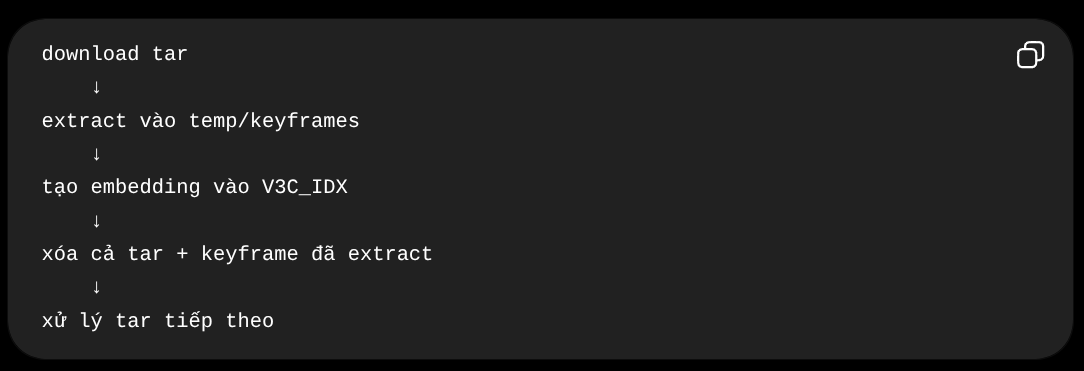

In [ ]:
%%bash
set -euo pipefail

REPO="trinhkhng/V3C_F"

SCRIPT_DIR="/kaggle/working/TempoRun_hf/TempoRun2026_Baseline"
IDX_DIR="$SCRIPT_DIR/V3C_IDX_SIGLIP2_G384"

WORK_DIR="/kaggle/working/temp_shard"
DOWNLOAD_DIR="$WORK_DIR/download"
KF_STAGE="$WORK_DIR/keyframes"
DONE_DIR="/kaggle/working/completed_shards_siglip2_g384"

NUM_SHARDS=7

MODEL_NAME="ViT-gopt-16-SigLIP2-384"
PRETRAINED="webli"
MODEL_PATH=""

if python -c 'import torch; exit(0 if torch.cuda.is_available() else 1)'; then
    DEVICE="cuda"
    PRECISION="fp16"
else
    DEVICE="cpu"
    PRECISION="fp32"
fi

echo "Device: $DEVICE"
echo "Precision: $PRECISION"

mkdir -p "$IDX_DIR" "$DOWNLOAD_DIR" "$DONE_DIR"

for ((i=0; i<NUM_SHARDS; i++)); do
    NAME=$(printf "v3c-kf-%05d.tar" "$i")

    FILE="$DOWNLOAD_DIR/$NAME"
    DONE="$DONE_DIR/$NAME.done"
    URL="https://huggingface.co/datasets/$REPO/resolve/main/$NAME?download=true"

    if [[ -f "$DONE" ]]; then
        echo "Skip $NAME: embedding đã hoàn thành"
        continue
    fi

    # Dọn keyframe của lần chạy lỗi trước
    rm -rf "$KF_STAGE"
    mkdir -p "$KF_STAGE"

    echo "===== Processing $NAME ====="

    echo "Downloading..."
    wget -c "$URL" -O "$FILE"

    echo "Checking tar..."
    tar -tf "$FILE" >/dev/null

    echo "Extracting..."
    tar -xf "$FILE" -C "$KF_STAGE"

    FIRST_TS=$(find "$KF_STAGE" -type f -name "ts_ms.npy" -print -quit)

    if [[ -z "$FIRST_TS" ]]; then
        echo "ERROR: Không tìm thấy ts_ms.npy trong $NAME"
        exit 1
    fi

    VIDEO_DIR=$(dirname "$FIRST_TS")
    KF_ROOT=$(dirname "$VIDEO_DIR")

    echo "Keyframe root: $KF_ROOT"
    echo "Output index:  $IDX_DIR"

    CMD=(
        python -u "$SCRIPT_DIR/extract_embed.py"
        --keyframes "$KF_ROOT"
        --out "$IDX_DIR"
        --device "$DEVICE"
        --model "$MODEL_NAME"
        --pretrained "$PRETRAINED"
        --precision "$PRECISION"
        --batch-size 4
        --shard-index 0
        --shard-count 1
        --limit 0
        --max_length 64
    )

    if [[ -n "$MODEL_PATH" && -f "$MODEL_PATH" ]]; then
        CMD+=(--pth_dir "$MODEL_PATH")
    fi

    echo "Creating embeddings..."
    printf 'Command: %q ' "${CMD[@]}"
    echo

    "${CMD[@]}"

    # Chỉ đánh dấu sau khi embedding thành công
    touch "$DONE"

    echo "Deleting extracted keyframes and tar..."
    rm -rf "$KF_STAGE"
    rm -f "$FILE"

    echo "Completed $NAME"
    df -h /kaggle/working
    du -sh "$IDX_DIR"
done

echo "===== ALL SHARDS COMPLETED ====="

In [ ]:
# ===== CẤU HÌNH RETRIEVAL =====
from pathlib import Path
import torch

BASE_DIR = Path("/kaggle/working/TempoRun_hf/TempoRun2026_Baseline")
SHARDS_DIR = BASE_DIR / "V3C_IDX_SIGLIP2_G384" / "shards"
TASKS_FILE = Path("/kaggle/working/TempoRun_hf/public_round_tasks.jsonl")
OUTPUT_FILE = Path("/kaggle/working/TempoRun_hf/submission.json")

MODEL_NAME = "ViT-gopt-16-SigLIP2-384"
PRETRAINED = "webli"
DEVICE = "cuda:0" if torch.cuda.is_available() else "cpu"
PRECISION = "fp16" if torch.cuda.is_available() else "fp32"
MAX_LENGTH = 64
CAND_KEYFRAMES = 400
TOP_VIDEOS = 10
RENORMALIZE_INDEX = False  # encode_images đã normalize thì để False

# Để chuỗi rỗng nếu chỉ chạy pretrained SigLIP2 Stage 1.
ELIP_CHECKPOINT = ""

# Chỉ cần khi ELIP_CHECKPOINT khác rỗng. Phải chứa lại ảnh keyframe gốc.
KEYFRAME_DIR = BASE_DIR / "V3C_KF"
ELIP_REPO = Path("/kaggle/working/ELIP")

# Tuỳ chọn: để rỗng nếu không dùng LoRA.
LORA_CHECKPOINT = ""

print(f"Device: {DEVICE} | Precision: {PRECISION}")
print(f"Shards: {SHARDS_DIR}")
print(f"ELIP: {'ON' if ELIP_CHECKPOINT else 'OFF (Stage 1 only)'}")

In [ ]:
# ===== CHẠY RETRIEVAL =====
import shlex
import subprocess
import sys

SCRIPT = BASE_DIR / "retrieve_elip_s2.py"

if not SCRIPT.is_file():
    raise FileNotFoundError(f"Không tìm thấy script: {SCRIPT}")
if not SHARDS_DIR.is_dir() or not next(SHARDS_DIR.glob("*.npz"), None):
    raise FileNotFoundError(f"Không có shard .npz trong: {SHARDS_DIR}")
if not TASKS_FILE.is_file():
    raise FileNotFoundError(f"Không tìm thấy task file: {TASKS_FILE}")

cmd = [
    sys.executable, "-u", str(SCRIPT),
    "--shards", str(SHARDS_DIR),
    "--tasks", str(TASKS_FILE),
    "--out", str(OUTPUT_FILE),
    "--model", MODEL_NAME,
    "--pretrained", PRETRAINED,
    "--precision", PRECISION,
    "--device", DEVICE,
    "--max-length", str(MAX_LENGTH),
    "--cand-keyframes", str(CAND_KEYFRAMES),
    "--top-videos", str(TOP_VIDEOS),
]

if RENORMALIZE_INDEX:
    cmd.append("--renormalize-index")

if LORA_CHECKPOINT:
    lora_path = Path(LORA_CHECKPOINT).expanduser().resolve()
    if not lora_path.is_file():
        raise FileNotFoundError(f"Không tìm thấy LoRA checkpoint: {lora_path}")
    cmd += ["--lora-checkpoint", str(lora_path)]

if ELIP_CHECKPOINT:
    import importlib.util
    import shutil

    elip_path = Path(ELIP_CHECKPOINT).expanduser().resolve()
    if not elip_path.is_file():
        raise FileNotFoundError(f"Không tìm thấy ELIP checkpoint: {elip_path}")
    if not KEYFRAME_DIR.is_dir():
        raise FileNotFoundError(
            f"ELIP cần ảnh keyframe gốc nhưng không thấy: {KEYFRAME_DIR}"
        )
    first_keyframe = next(KEYFRAME_DIR.glob("*/*.jpg"), None)
    if first_keyframe is None:
        raise FileNotFoundError(
            "KEYFRAME_DIR không chứa <video_id>/*.jpg. Cell embedding đã "
            "xóa keyframe tạm; hãy trỏ KEYFRAME_DIR tới Kaggle Input "
            "hoặc một thư mục keyframe được giữ lại."
        )

    # Chỉ cài/patch môi trường ELIP khi thật sự có checkpoint.
    subprocess.run([
        sys.executable, "-m", "pip", "install", "-q",
        "timm==1.0.14", "transformers==4.49.0", "ipdb"
    ], check=True)
    if not (ELIP_REPO / ".git").is_dir():
        subprocess.run([
            "git", "clone", "--depth", "1",
            "https://github.com/ypliubit/ELIP.git", str(ELIP_REPO)
        ], check=True)

    timm_spec = importlib.util.find_spec("timm")
    if timm_spec is None or not timm_spec.submodule_search_locations:
        raise RuntimeError("Không tìm thấy package timm")
    timm_models = Path(next(iter(timm_spec.submodule_search_locations))) / "models"
    patch_dir = ELIP_REPO / "ELIP-C" / "ELIPC_env_code"
    for filename in ("vision_transformer.py", "vision_transformer_hybrid.py"):
        shutil.copy2(patch_dir / filename, timm_models / filename)
    cmd += [
        "--elip-checkpoint", str(elip_path),
        "--keyframes", str(KEYFRAME_DIR),
        "--elip-repo", str(ELIP_REPO),
    ]

print("Running:", shlex.join(cmd))
subprocess.run(cmd, cwd=BASE_DIR, check=True)
print(f"Đã tạo: {OUTPUT_FILE}")

In [ ]:
# ===== NÉN SUBMISSION =====
import zipfile

if not OUTPUT_FILE.is_file():
    raise FileNotFoundError(f"Chưa có submission: {OUTPUT_FILE}")

ZIP_FILE = OUTPUT_FILE.with_suffix(".zip")
with zipfile.ZipFile(ZIP_FILE, "w", zipfile.ZIP_DEFLATED) as zip_ref:
    zip_ref.write(OUTPUT_FILE, arcname="submission.json")

print(f"Finish: {ZIP_FILE}")